In [8]:
import os, matplotlib, math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
import copy

matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
})
%matplotlib inline

ORANGE = '#ff7f0e'
GREEN = '#2ca02c'

In [9]:
data = pd.read_csv('original_annotation_file.csv')

### DATA EVALUATION

In [10]:
def find_zscore_bound(data, bound=3):
    z = zscore(data)
    all = pd.DataFrame({'values':data,'z':z})
    return all[all['z']>bound].sort_values('z').iloc[0]['values']

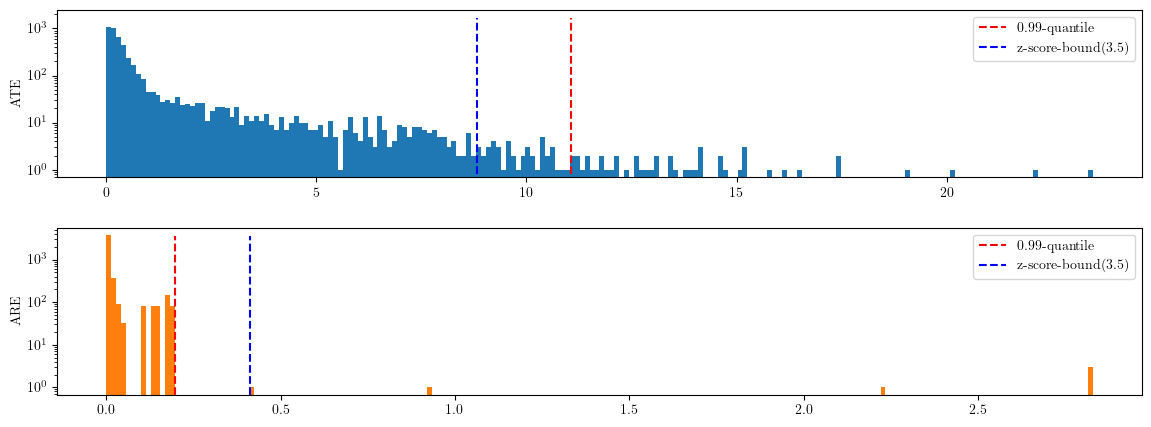

In [34]:
figs, axs = plt.subplots(2, 1, figsize=(14,5))
plt.subplots_adjust(hspace=0.3)
axs[0].hist(data['ate'], bins=200)
axs[0].plot([data['ate'].quantile(.99)]*2, [0, 1700], '--', color='red', label='0.99-quantile')
axs[0].plot([find_zscore_bound(data['ate'],bound=3.5)]*2, [0, 1700], '--', color='blue', label='z-score-bound(3.5)')
axs[1].hist(data['are'], bins=200, color=ORANGE)
axs[1].plot([data['are'].quantile(.99)]*2, [0, 3500], '--', color='red', label='0.99-quantile')
axs[1].plot([find_zscore_bound(data['are'],bound=3.5)]*2, [0, 3500], '--', color='blue', label='z-score-bound(3.5)')
axs[0].set_ylabel('ATE')
axs[1].set_ylabel('ARE')
axs[0].set_yticks([])
axs[1].set_yticks([])
axs[0].legend()
axs[1].legend()
axs[0].set_yscale('log')
axs[1].set_yscale('log')
plt.savefig('APE_box.pdf', bbox_inches='tight')

Text(0.5, 1.0, '$are$')

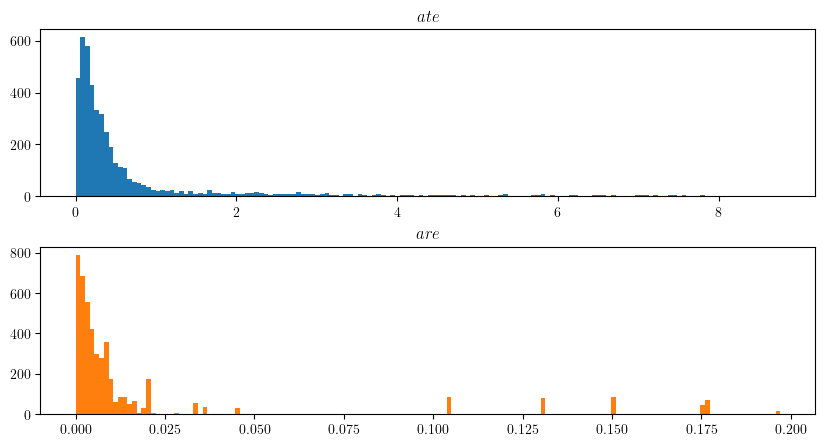

In [18]:
filtered = data[
    (data['are']<data['are'].quantile(.99))&(data['are']<find_zscore_bound(data['are'],bound=3.5))&
    (data['ate']<data['ate'].quantile(.99))&(data['ate']<find_zscore_bound(data['ate'],bound=3.5))
].copy()

_, axs = plt.subplots(2, 1, figsize=(10,5))
plt.subplots_adjust(hspace=0.3)
axs[0].hist(filtered['ate'], bins=150)
axs[1].hist(filtered['are'], bins=150, color=ORANGE)
axs[0].set_title('$ate$')
axs[1].set_title('$are$')

In [30]:
len(data)-len(filtered)

118

### AREA CORRELATION 

Text(0.5, 0, 'area')

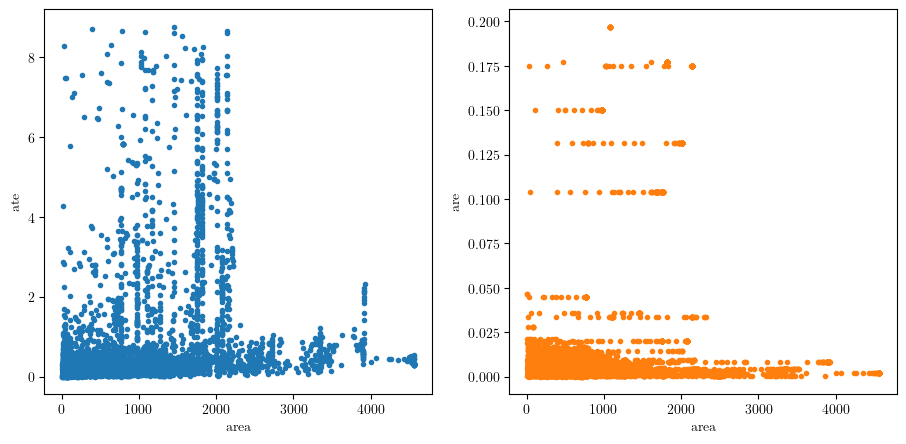

In [31]:
_, axs = plt.subplots(1, 2, figsize=(11,5))
axs[0].scatter(filtered['area'],filtered['ate'],marker='.')
axs[1].scatter(filtered['area'],filtered['are'],marker='.',color=ORANGE)
axs[0].set_ylabel('ate')
axs[1].set_ylabel('are')
axs[0].set_xlabel('area')
axs[1].set_xlabel('area')

### LOG RESCALE

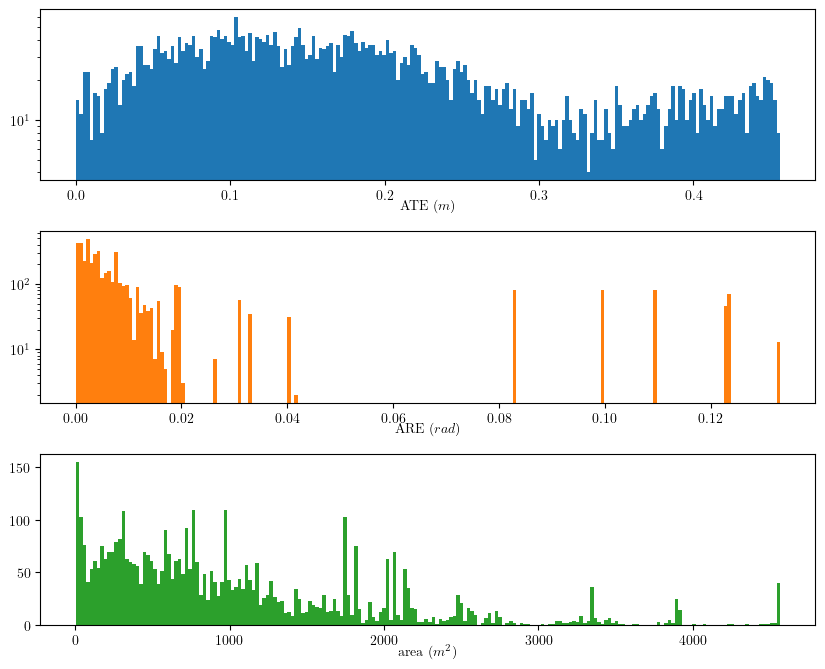

In [23]:
filtered['ate'] =  np.log1p(filtered['ate'])
filtered['are'] =  np.log1p(filtered['are'])
filtered['area'] = filtered['area']

_, axs = plt.subplots(3, 1, figsize=(10,8))
plt.subplots_adjust(hspace=0.3)
axs[0].hist(filtered['ate'], bins=200)
axs[1].hist(filtered['are'], bins=200, color=ORANGE)
axs[2].hist(filtered['area'], bins=200, color=GREEN)
for ax in axs:
    ax.xaxis.labelpad = -2  # riduci lo spazio tra label e figura

axs[0].set_xlabel('ATE ($m$)')
axs[1].set_xlabel('ARE ($rad$)')
axs[2].set_xlabel('area ($m^2$)')
axs[0].set_yscale('log')
axs[1].set_yscale('log')

### RESCALE

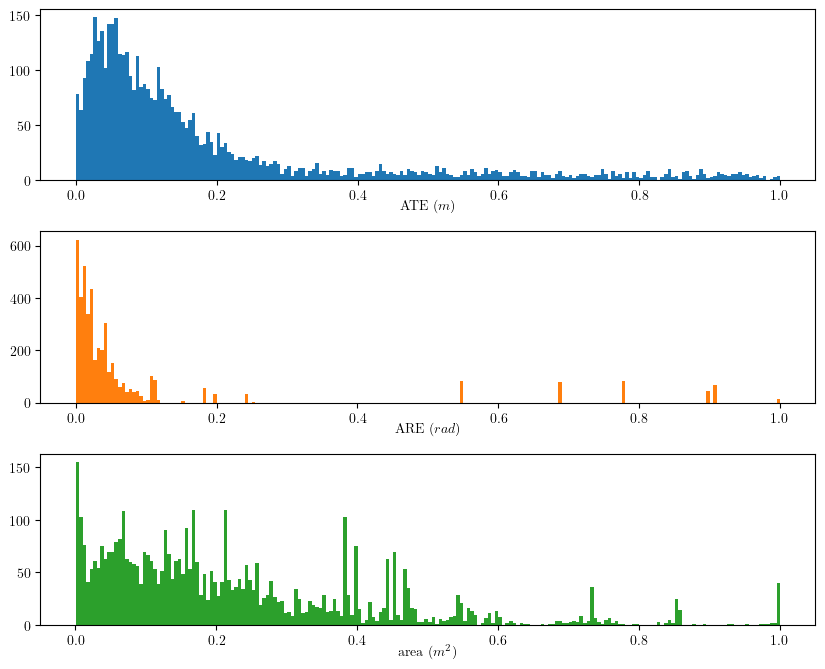

In [33]:
filtered['ate'] /= filtered['ate'].max()
filtered['are'] /= filtered['are'].max()
filtered['area'] /= filtered['area'].max()

_, axs = plt.subplots(3, 1, figsize=(10,8))
plt.subplots_adjust(hspace=0.3)
axs[0].hist(filtered['ate'], bins=200)
axs[1].hist(filtered['are'], bins=200, color=ORANGE)
axs[2].hist(filtered['area'], bins=200, color=GREEN)
for ax in axs:
    ax.xaxis.labelpad = -2  # riduci lo spazio tra label e figura

axs[0].set_xlabel('ATE ($m$)')
axs[1].set_xlabel('ARE ($rad$)')
axs[2].set_xlabel('area ($m^2$)')

plt.savefig('APE_norm_hist.pdf', bbox_inches='tight')

In [34]:
filtered.to_csv('annotation_file.csv',index=False)